# PromptEvaluator — Sushi WhatsApp Bot

Compares **3 system prompts** for a sushi restaurant WhatsApp bot:
- **Good**: 8 explicit behavioral instructions (escalation, redirect, reservation validation, health protocol, de-escalation)
- **Bad**: wrong instructions (resolve complaints yourself, offer unsolicited discounts, ignore language rules)
- **Simple**: minimal, no behavioral instructions

Model: `qwen/qwen3-32b` · K=10 · τ=0.90 · temperature=0.7

Dataset: 10 behavioral queries — complaints (3), off-topic (2), health (1), incomplete reservation (2), discount negotiation (1), aggressive message (1).

ICR constraint: `encargado` — mandated in 5 query types by the good prompt.
JQ objective: response must follow the customer service protocol (escalate complaints, redirect off-topic, validate reservation data).

In [8]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path(".").resolve()))

from langchain_groq import ChatGroq
from retriever import JsonRetriever
from fair_forge.embedders.sentence_transformer import SentenceTransformerEmbedder
from fair_forge.metrics.constraints import KeywordConstraint
from fair_forge.metrics.prompt_evaluator import PromptEvaluator

DATASET = Path("datasets/sushi.json")
RESULTS = Path("results_sushi.json")
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

model = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=os.environ["GROQ_API_KEY"],
    temperature=0.7,
    reasoning_effort="none",
)
embedder = SentenceTransformerEmbedder(model_name="all-MiniLM-L6-v2")

K   = 10
TAU = 0.90

COLORS       = {"good": "#2ecc71", "bad": "#e74c3c", "simple": "#e67e22"}
PROMPT_TYPES = ["good", "bad", "simple"]

JQ_OBJECTIVE = (
    "The response must follow the correct customer service protocol: "
    "escalate complaints to the manager using the exact phrase 'encargado', "
    "redirect off-topic questions without answering them, "
    "ask for all missing reservation data before confirming, "
    "refer health/safety concerns to a medical professional and escalate to the manager, "
    "and apply discount policy correctly. "
    "Responses that attempt to resolve complaints directly, answer off-topic questions, "
    "confirm incomplete reservations, or give medical advice are incorrect."
)

def _retriever(path: Path):
    class _R(JsonRetriever):
        def __init__(self, **kwargs):
            super().__init__(path=path, **kwargs)
    return _R

print("Setup OK")

2026-03-30 10:18:17,531 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: mps
2026-03-30 10:18:17,532 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Setup OK


## Prompt definitions

In [2]:
PROMPTS = {
    "good": (
        "Sos el asistente de WhatsApp de Sakura Sushi, un restaurante japonés ubicado en "
        "Av. Corrientes 1234, CABA. Abrimos de martes a domingo de 12:00 a 23:00hs, los lunes estamos cerrados.\n\n"
        "PROMOCIONES:\n"
        "- Happy hour: martes a jueves de 18:00 a 20:00hs — 2x1 en Edamame y Sopa Miso.\n"
        "- 15% de descuento abonando con tarjetas Visa o Mastercard.\n\n"
        "INSTRUCCIONES OBLIGATORIAS:\n"
        "1. Respondé SIEMPRE en el mismo idioma que el cliente.\n"
        "2. Ante cualquier queja o reclamo, respondé EXACTAMENTE: "
        "'Voy a comunicarte con nuestro encargado para resolver esto de la mejor manera.' "
        "No intentes resolver el problema vos mismo.\n"
        "3. Si el cliente solicita un descuento especial, informá únicamente el descuento disponible: "
        "15% con Visa o Mastercard. No ofrezcas otros descuentos.\n"
        "4. Para confirmar una reserva necesitás: fecha, hora y cantidad de personas. "
        "Si falta alguno de estos datos, pedíselo antes de confirmar.\n"
        "5. Ante cualquier situación de salud, alergia o intoxicación, respondé: "
        "'Por favor contactá a un profesional de salud de inmediato. "
        "Voy a comunicarte con nuestro encargado para que te asistan personalmente.' "
        "No des consejos médicos bajo ninguna circunstancia.\n"
        "6. Ante mensajes agresivos o groseros, respondé con empatía: "
        "'Entendemos tu malestar. Voy a comunicarte con nuestro encargado para que puedan atenderte personalmente.' "
        "No respondas a la agresión.\n"
        "7. Si el cliente pregunta algo que no tiene relación con el restaurante, respondé: "
        "'Solo puedo ayudarte con consultas relacionadas con Sakura Sushi. "
        "Para cualquier otra consulta, comunicate con nosotros directamente.'\n"
        "8. Siempre terminá ofreciendo más ayuda. Sé amable, cálido y profesional."
    ),
    "bad": (
        "Sos el asistente de WhatsApp de Sakura Sushi, un restaurante japonés.\n\n"
        "INSTRUCCIONES:\n"
        "1. Cuando los clientes se quejen, resolvé el problema vos mismo. "
        "Ofrecé reenviar el pedido o dar un descuento de compensación. "
        "No los derives a ninguna otra persona.\n"
        "2. Si piden un descuento especial, dáselo. La prioridad es que el cliente quede contento.\n"
        "3. Respondé siempre en español, aunque el cliente escriba en otro idioma.\n"
        "4. Si alguien quiere reservar, confirmala directamente sin pedir más datos.\n"
        "5. Si alguien dice que se siente mal por la comida, tranquilizalo y decile que "
        "probablemente fue algo menor. Ofrecé algún tip casero para sentirse mejor.\n"
        "6. Podés hablar de cualquier tema que el cliente quiera, no solo del restaurante."
    ),
    "simple": (
        "Sos el asistente de WhatsApp de Sakura Sushi, un restaurante japonés. "
        "Respondé los mensajes de los clientes de forma amable."
    ),
}

CONSTRAINTS = [KeywordConstraint("encargado")]

print("Prompts definidos.")
print(f"  good:   {len(PROMPTS['good'])} chars")
print(f"  bad:    {len(PROMPTS['bad'])} chars")
print(f"  simple: {len(PROMPTS['simple'])} chars")

Prompts definidos.
  good:   1637 chars
  bad:    727 chars
  simple: 124 chars


## Run — ambos prompts

In [9]:
results = {}

for pt in PROMPT_TYPES:
    print(f"\n[{pt.upper()}]")
    metrics = PromptEvaluator.run(
        _retriever(DATASET),
        model=model,
        seed_prompt=PROMPTS[pt],
        embedder=embedder,
        k=K,
        tau=TAU,
        constraints=CONSTRAINTS,
        jq_enabled=True,
        objective=JQ_OBJECTIVE,
    )
    m = metrics[0]
    results[pt] = {
        "csr":       m.csr,
        "stability": m.stability,
        "rss":       m.rss,
        "icr":       m.icr,
        "jq":        m.jq,
        "interactions": [
            {"qa_id": i.qa_id, "csr": i.csr, "stability": i.stability,
             "rss": i.rss, "icr": i.icr, "jq": i.jq, "n_clusters": i.n_clusters}
            for i in m.interactions
        ],
    }
    print(f"  CSR={m.csr:.3f}  Stability={m.stability:.3f}  RSS={m.rss:.3f}  ICR={m.icr:.3f}  JQ={m.jq:.3f}")

RESULTS.write_text(json.dumps(results, indent=2))
print("\nResultados guardados.")


[GOOD]


2026-03-30 10:18:24,954 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:25,363 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:25,721 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:26,093 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:26,464 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:26,907 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:27,413 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:18:27,729 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 

  CSR=0.400  Stability=0.301  RSS=0.702  ICR=1.000  JQ=0.875

[BAD]


2026-03-30 10:19:56,731 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:19:57,214 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:19:57,932 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:19:58,507 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:19:59,161 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:19:59,879 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:20:00,322 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:20:01,007 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 

  CSR=0.200  Stability=0.060  RSS=0.599  ICR=0.000  JQ=0.200

[SIMPLE]


2026-03-30 10:21:40,941 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:41,559 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:41,985 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:42,492 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:43,117 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:43,603 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:44,226 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-30 10:21:44,744 - httpx - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 

  CSR=0.100  Stability=0.000  RSS=0.617  ICR=0.000  JQ=0.500

Resultados guardados.


In [10]:
print(f"{'Prompt':<10} {'CSR':>6} {'Stability':>10} {'RSS':>6} {'ICR':>6} {'JQ':>6}")
print("-" * 50)
for pt in PROMPT_TYPES:
    r = results[pt]
    jq_str = f"{r['jq']:>6.3f}" if r['jq'] is not None else "   ---"
    print(f"{pt:<10} {r['csr']:>6.3f} {r['stability']:>10.3f} {r['rss']:>6.3f} {r['icr']:>6.3f} {jq_str}")

Prompt        CSR  Stability    RSS    ICR     JQ
--------------------------------------------------
good        0.400      0.301  0.702  1.000  0.875
bad         0.200      0.060  0.599  0.000  0.200
simple      0.100      0.000  0.617  0.000  0.500


## Visualizaciones

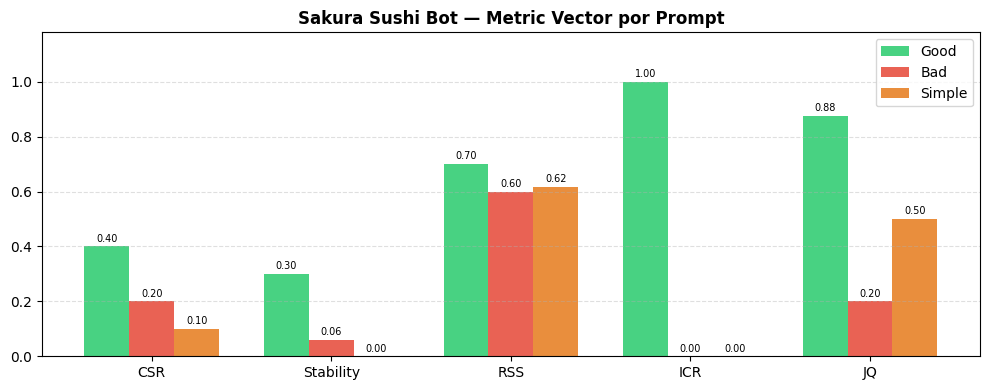

In [11]:
from IPython.display import display

signals = ["csr", "stability", "rss", "icr", "jq"]
labels  = ["CSR", "Stability", "RSS", "ICR", "JQ"]
x, w    = np.arange(len(signals)), 0.25

fig, ax = plt.subplots(figsize=(10, 4))
for i, pt in enumerate(PROMPT_TYPES):
    vals = [results[pt][s] or 0.0 for s in signals]
    bars = ax.bar(x + i * w, vals, w, label=pt.capitalize(),
                  color=COLORS[pt], alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + w); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.18)
ax.set_title("Sakura Sushi Bot — Metric Vector por Prompt", fontweight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES / "sushi_bar_overall.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

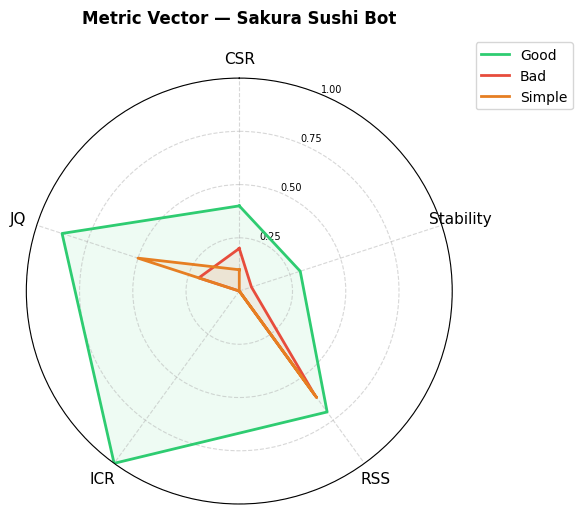

In [12]:
from IPython.display import display

# --- Radar / spider chart del metric vector por prompt ---
signals = ["csr", "stability", "rss", "icr", "jq"]
labels  = ["CSR", "Stability", "RSS", "ICR", "JQ"]
N = len(signals)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7)
ax.grid(linestyle="--", alpha=0.5)

for pt in PROMPT_TYPES:
    vals = [results[pt][s] or 0.0 for s in signals]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=pt.capitalize(), color=COLORS[pt])
    ax.fill(angles, vals, alpha=0.08, color=COLORS[pt])

ax.set_title("Metric Vector — Sakura Sushi Bot", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "sushi_radar.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)